In [3]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Our modules
from src.data_loader import load_data
from src.cleaning import remove_nulls, normalize_timezone
from src.indicators import add_all_indicators
from src.sentiment import aggregate_daily_sentiment
from src.sentiment import add_sentiment_scores


plt.style.use('seaborn-v0_8')
%matplotlib inline

In [4]:
# Load News Data
news = load_data('../data/raw/news.csv', index_col=0, parse_dates=['date'])
news = normalize_timezone(news, 'date')
news = remove_nulls(news)

print("News shape:", news.shape)
print("Date range:", news['date'].min(), "to", news['date'].max())

# Load Stock Data - AMZN
stock = load_data('../data/raw/stockData/AMZN.csv', 
                  index_col='Date', 
                  parse_dates=True)

print("Stock shape:", stock.shape)
print("Stock date range:", stock.index.min(), "to", stock.index.max())

News shape: (1407328, 5)
Date range: 2009-02-14 00:00:00+00:00 to 2020-06-11 21:12:35+00:00
Stock shape: (3774, 5)
Stock date range: 2009-01-02 00:00:00 to 2023-12-29 00:00:00


In [5]:
# Add all indicators
stock = add_all_indicators(stock)

# Show latest rows
stock[['Close', 'SMA_20', 'RSI', 'BB_Upper', 'BB_Lower', 'Daily_Return']].tail()

,Close,SMA_20,RSI,BB_Upper,BB_Lower,Daily_Return
Date,,,,,,
2023-12-22,153.419998,148.578999,64.115558,154.696716,142.461283,-0.273010
2023-12-26,153.410004,148.863000,64.085644,155.314929,142.411071,-0.006514
2023-12-27,153.339996,149.178500,63.860893,155.854273,142.502726,-0.045634
2023-12-28,153.380005,149.531499,63.938728,156.311164,142.751835,0.026091
2023-12-29,151.940002,149.824000,59.012257,156.488309,143.159691,-0.938846


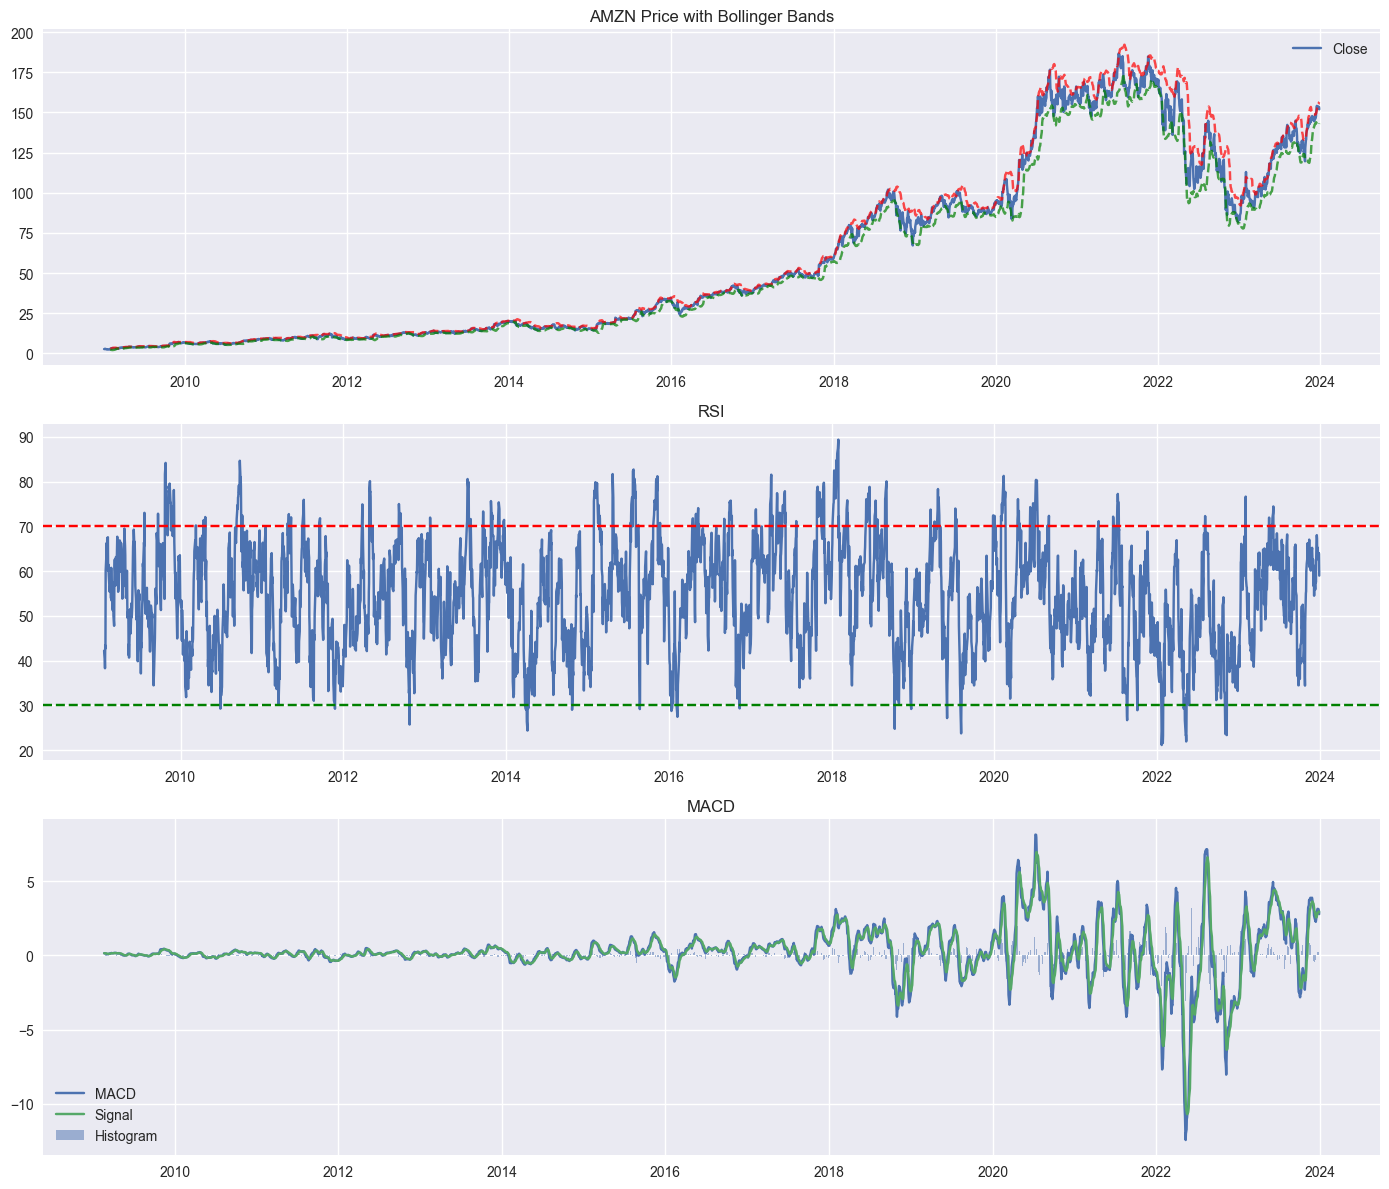

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Price + Bollinger Bands
axes[0].plot(stock.index, stock['Close'], label='Close')
axes[0].plot(stock.index, stock['BB_Upper'], 'r--', alpha=0.7)
axes[0].plot(stock.index, stock['BB_Lower'], 'g--', alpha=0.7)
axes[0].set_title('AMZN Price with Bollinger Bands')
axes[0].legend()

# RSI
axes[1].plot(stock.index, stock['RSI'])
axes[1].axhline(70, color='r', linestyle='--')
axes[1].axhline(30, color='g', linestyle='--')
axes[1].set_title('RSI')

# MACD
axes[2].plot(stock.index, stock['MACD'], label='MACD')
axes[2].plot(stock.index, stock['Signal'], label='Signal')
axes[2].bar(stock.index, stock['Histogram'], label='Histogram', alpha=0.5)
axes[2].set_title('MACD')
axes[2].legend()

plt.tight_layout()
plt.show()

In [7]:
# Get daily sentiment for AMZN
daily_sentiment = aggregate_daily_sentiment(news, 'AMZN')

print("Daily sentiment shape:", daily_sentiment.shape)
daily_sentiment.head()

Processing 278 articles for AMZN...
why cant i see this?
Applying VADER to 278 headlines...
getting sentiment for: How Cannabis Company Cannaphyll Is Marketing On Mass-Consumer Platforms, Google And Amazon
scores: {'neg': 0.0, 'neu': 0.866, 'pos': 0.134, 'compound': 0.1779}
getting sentiment for: Tech Stocks And FAANGS Strong Again To Start Day As Market Awaits Fed
scores: {'neg': 0.0, 'neu': 0.705, 'pos': 0.295, 'compound': 0.5574}
getting sentiment for: Benzinga Pro's Top 5 Stocks To Watch For Wed., Jun. 10, 2020: AAPL, BAC, NIO, SONO, GLW
scores: {'neg': 0.0, 'neu': 0.899, 'pos': 0.101, 'compound': 0.2023}
getting sentiment for: Hearing Vertical Group Out Positive On Amazon, Saying Co.'s Ad Spend Revenues Are Increasing As Shipping Bottleneck Issues Begin To Abate
scores: {'neg': 0.0, 'neu': 0.782, 'pos': 0.218, 'compound': 0.6486}
getting sentiment for: Big Tech Reaches New Record Heights At The Stock Market
scores: {'neg': 0.0, 'neu': 0.882, 'pos': 0.118, 'compound': 0.0516}
getti

,date,avg_sentiment,pos,neg,neu,article_count,sentiment_category
0,2020-04-27,0.128317,0.092667,0.000000,0.907333,6,Positive
1,2020-04-28,-0.006619,0.116687,0.072563,0.810750,16,Neutral
2,2020-04-29,0.117593,0.119467,0.053733,0.826867,15,Positive
3,2020-04-30,0.195133,0.119926,0.021259,0.858815,27,Positive
4,2020-05-01,0.090476,0.083024,0.045390,0.871634,41,Positive


In [8]:
amzn_news = news[news['stock'] == 'AMZN'].copy()
print("Rows for AMZN:", len(amzn_news))
print("Null headlines:", amzn_news['headline'].isna().sum())
print(amzn_news['headline'].head(10))

Rows for AMZN: 278
Null headlines: 0
76869    How Cannabis Company Cannaphyll Is Marketing O...
76870    Tech Stocks And FAANGS Strong Again To Start D...
76871    Benzinga Pro's Top 5 Stocks To Watch For Wed.,...
76872    Hearing Vertical Group Out Positive On Amazon,...
76873    Big Tech Reaches New Record Heights At The Sto...
76874    Twitter, Square Will Mark Juneteenth As Holida...
76875    'Inside Amazon's plan to test warehouse worker...
76876    BofA Raises Amazon Target On Sales Upside, Acc...
76877    Amazon shares are trading higher despite marke...
76878    IRS Alerts Against Criminals Profiteering From...
Name: headline, dtype: object


In [9]:
# === Prepare Stock Data ===
stock_daily = stock[['Daily_Return']].copy()
stock_daily = stock_daily.reset_index()

# Make sure date column is in the same format (date only)
stock_daily['date'] = pd.to_datetime(stock_daily['Date']).dt.date

print("Stock days:", len(stock_daily))
print("Sentiment days:", len(daily_sentiment))

# === Merge Sentiment + Stock Returns ===
merged = pd.merge(
    daily_sentiment,
    stock_daily,
    on='date',
    how='inner'          # Only keep days where we have BOTH news and stock data
)

print("✅ Merged shape:", merged.shape)
print("Date range:", merged['date'].min(), "to", merged['date'].max())

merged.head()

Stock days: 3774
Sentiment days: 37
✅ Merged shape: (28, 9)
Date range: 2020-04-27 to 2020-06-10


,date,avg_sentiment,pos,neg,neu,article_count,sentiment_category,Date,Daily_Return
0,2020-04-27,0.128317,0.092667,0.000000,0.907333,6,Positive,2020-04-27,-1.419786
1,2020-04-28,-0.006619,0.116687,0.072563,0.810750,16,Neutral,2020-04-28,-2.606061
2,2020-04-29,0.117593,0.119467,0.053733,0.826867,15,Positive,2020-04-29,2.533616
3,2020-04-30,0.195133,0.119926,0.021259,0.858815,27,Positive,2020-04-30,4.268957
4,2020-05-01,0.090476,0.083024,0.045390,0.871634,41,Positive,2020-05-01,-7.597409


=== Average Daily Return by Sentiment Category ===

                    Daily_Return  num_days
sentiment_category                        
Negative                  0.0554         1
Neutral                   0.0962         4
Positive                  0.3281        23


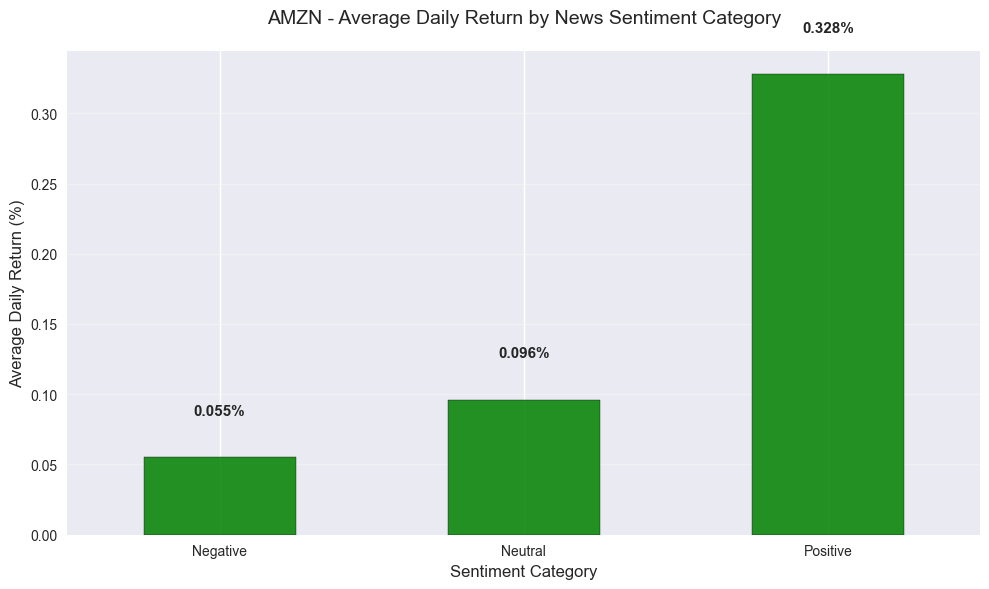

In [10]:
# Average Daily Return by Sentiment
avg_return = merged.groupby('sentiment_category')['Daily_Return'].mean().round(4)
count_per_category = merged.groupby('sentiment_category').size()

print("=== Average Daily Return by Sentiment Category ===\n")
result = pd.concat([avg_return, count_per_category.rename('num_days')], axis=1)
print(result)

# === Bar Chart ===
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' if x < 0 else 'gray' for x in avg_return]

bars = avg_return.plot(kind='bar', color=colors, alpha=0.85, edgecolor='black')

plt.title('AMZN - Average Daily Return by News Sentiment Category', fontsize=14, pad=20)
plt.ylabel('Average Daily Return (%)', fontsize=12)
plt.xlabel('Sentiment Category', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(avg_return):
    plt.text(i, v + (0.03 if v >= 0 else -0.08), 
             f"{v:.3f}%", 
             ha='center', 
             fontsize=11, 
             fontweight='bold')

plt.tight_layout()
plt.show()

Correlation between Average Sentiment Score and Daily Return: 0.1668


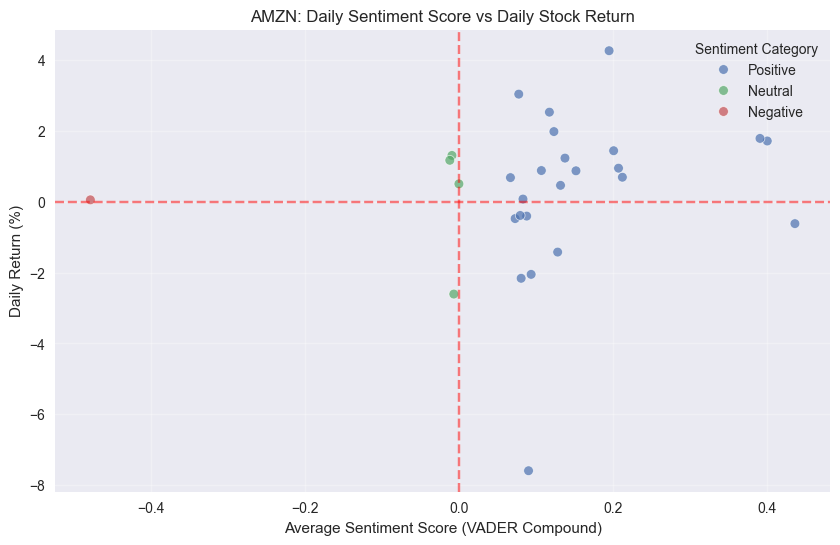

In [11]:
# Correlation
correlation = merged['avg_sentiment'].corr(merged['Daily_Return'])
print(f"Correlation between Average Sentiment Score and Daily Return: {correlation:.4f}")

# Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged, x='avg_sentiment', y='Daily_Return', alpha=0.7, hue='sentiment_category')
plt.title('AMZN: Daily Sentiment Score vs Daily Stock Return')
plt.xlabel('Average Sentiment Score (VADER Compound)')
plt.ylabel('Daily Return (%)')
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.legend(title='Sentiment Category')
plt.show()

In [ ]:
print("=== Summary Statistics for AMZN ===")
print(f"Total trading days with news: {len(merged)}")
print(f"Positive sentiment days : {count_per_category.get('Positive', 0)}")
print(f"Neutral sentiment days  : {count_per_category.get('Neutral', 0)}")
print(f"Negative sentiment days : {count_per_category.get('Negative', 0)}")
print(f"Best average return     : {avg_return.max():.3f}% on {avg_return.idxmax()}")
print(f"Worst average return    : {avg_return.min():.3f}% on {avg_return.idxmin()}")

=== Summary Statistics for amzn ===
Total trading days with news: 28
Positive sentiment days : 23
Neutral sentiment days  : 4
Negative sentiment days : 1
Best average return     : 0.328% on Positive
Worst average return    : 0.055% on Negative
